# Deep Neural Network using Keras

In [ ]:
import tensorflow as tf

from tensorflow.keras import models
from tensorflow.keras import layers

import random
import numpy as np

In [ ]:
random.seed(42)         # Initialize the random number generator.
np.random.seed(42)      # With the seed reset, the same set of
                        # numbers will appear every time.
#tf.set_random_seed(42)  # sets the graph-level random seed

## Dataset

In [ ]:
# Use the MNIST dataset  of Keras.

mnist = tf.keras.datasets.mnist

(Xtrain, Ytrain) , (Xtest, Ytest) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


Text(0.5, 1.0, 'Ground Truth (Test): 7')

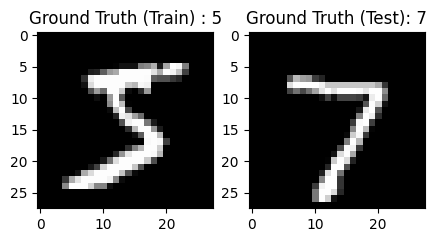

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(Xtrain[0,:,:], cmap='gray')
plt.title("Ground Truth (Train) : {}".format(Ytrain[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(Xtest[0,:,:], cmap='gray')
plt.title("Ground Truth (Test): {}".format(Ytest[0]))

In [ ]:
# size of the datsets

print(Xtrain.shape)
print(Xtest.shape)
print(Ytrain.shape)
print(Ytest.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [ ]:
# print a sample data

print('Xtrain \n', Xtrain[10,10])
print('Xtest \n', Xtest[10,10])
print('Ytrain \n', Ytrain[10,])
print('Ytest \n', Ytest[10,])

Xtrain 
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  24 209 254 254 254
 171   0   0   0   0   0   0   0   0   0]
Xtest 
 [  0   0   0   0   0   0   0   0 194 254 103   0   0   0   0   0   0   0
   0   0 150 254 213   0   0   0   0   0]
Ytrain 
 3
Ytest 
 0


In [ ]:
# Normalize the data
# 60000 input images are in the train set.
# 10000 input images are in the test set.

Xtrain = Xtrain.reshape((60000, 28*28))    # reshape the input set to size 28*28.
Xtrain = Xtrain.astype('float32')/255      # normalize to grayscale; set datatype as float32

Xtest = Xtest.reshape((10000, 28*28))      # reshape the input set to size 28*28.
Xtest = Xtest.astype('float32')/255        # normalize to grayscale; set datatype as float32

Ytrain = tf.keras.utils.to_categorical(Ytrain)
Ytest = tf.keras.utils.to_categorical(Ytest)

In [ ]:
# print a sample data

print('Xtrain \n', Xtrain[10,10])
print('Xtest \n', Xtest[10,10])
print('Ytrain \n', Ytrain[10,])
print('Ytest \n', Ytest[10,])

Xtrain 
 0.0
Xtest 
 0.0
Ytrain 
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
Ytest 
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## DNN Model

Using Keras, create the DNN or Sequential Model

In [ ]:
# Create a model object

dnnModel = models.Sequential()

Add dense layers, specifying the number of units in each layer and the activation function used in the layer.

In [ ]:
# Layer 1 = hidden layer
# specify the input size in the first layer.MLP

dnnModel.add(layers.Dense(50, activation='relu', input_shape= (28*28,)))

# Layer 2 = hidden layer
dnnModel.add(layers.Dense(60, activation='relu'))

# Layer 3 = hidden layer
dnnModel.add(layers.Dense(30, activation='relu'))


# Layer 4 = output layer
# number of neurons = number of classes = 10
dnnModel.add(layers.Dense(10, activation='softmax'))

dnnModel.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                39250     
                                                                 
 dense_1 (Dense)             (None, 60)                3060      
                                                                 
 dense_2 (Dense)             (None, 30)                1830      
                                                                 
 dense_3 (Dense)             (None, 10)                310       
                                                                 
Total params: 44450 (173.63 KB)
Trainable params: 44450 (173.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# not required -> just the workflow
from tensorflow.python.keras.utils.vis_utils import plot_model
plot_model(dnnModel, to_file='2A DNN.png')
from IPython.display import Image
Image(filename='2A DNN.png')

NameError: name 'dnnModel' is not defined

## Regularization and Optimizations of DNN

In [ ]:
# Configure  the model for training, by using appropriate optimizers and regularizations
# Available optimizer: adam, rmsprop, adagrad, sgd
# loss:  objective that the model will try to minimize.
# Available loss: categorical_crossentropy, binary_crossentropy, mean_squared_error
# metrics: List of metrics to be evaluated by the model during training and testing.

dnnModel.compile( optimizer = 'sgd', loss = 'categorical_crossentropy', metrics=['accuracy'] )

## Train the Model

In [ ]:
# train the model



h  = dnnModel.fit( Xtrain, Ytrain, epochs=25, validation_split=0.1, batch_size=64)

Epoch 1/25
844/844 [==============================] - 4s 4ms/step - loss: 1.5417 - accuracy: 0.5424 - val_loss: 0.5591 - val_accuracy: 0.8618
Epoch 2/25
844/844 [==============================] - 4s 4ms/step - loss: 0.4797 - accuracy: 0.8681 - val_loss: 0.3175 - val_accuracy: 0.9160
Epoch 3/25
844/844 [==============================] - 3s 3ms/step - loss: 0.3607 - accuracy: 0.8977 - val_loss: 0.2673 - val_accuracy: 0.9292
Epoch 4/25
844/844 [==============================] - 3s 3ms/step - loss: 0.3134 - accuracy: 0.9106 - val_loss: 0.2416 - val_accuracy: 0.9338
Epoch 5/25
844/844 [==============================] - 3s 3ms/step - loss: 0.2811 - accuracy: 0.9196 - val_loss: 0.2176 - val_accuracy: 0.9377
Epoch 6/25
844/844 [==============================] - 4s 4ms/step - loss: 0.2558 - accuracy: 0.9258 - val_loss: 0.1966 - val_accuracy: 0.9460
Epoch 7/25
844/844 [==============================] - 3s 4ms/step - loss: 0.2343 - accuracy: 0.9326 - val_loss: 0.1821 - val_accuracy: 0.9468
Epoch 

In [ ]:
#print('Final training loss \t', h.history['loss'][-1])
print('Final training accuracy ', h.history['accuracy'][-1])
#print('Final training loss \t', h.history['val_loss'][-1])
print('Final validation accuracy ', h.history['val_accuracy'][-1])

Final training accuracy  0.9741296172142029
Final validation accuracy  0.971833348274231


## Testing the Model

In [ ]:
# testing the model

testLoss, testAccuracy = dnnModel.evaluate( Xtest, Ytest)

313/313 [==============================] - 1s 2ms/step - loss: 0.1126 - accuracy: 0.9656


In [ ]:
print('Testing loss \t', testLoss)
print('Testing accuracy ', testAccuracy)

Testing loss 	 0.1126275286078453
Testing accuracy  0.9656000137329102


In [ ]:
num_classes = 9

#traget names
target_names = ["Class {}".format(i) for i in range(num_classes)]

Ytrue = np.argmax(Ytest,axis = 1)

# Predict Labels
Ypredicted = dnnModel.predict(Xtest)
Ypredicted = np.argmax(np.round(Ypredicted),axis=1)


313/313 [==============================] - 1s 2ms/step


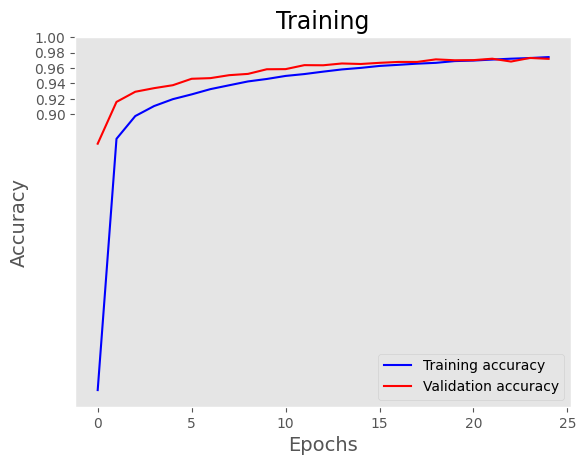

In [ ]:
import matplotlib.pyplot as plt

accuracy = h.history['accuracy']
val_accuracy = h.history['val_accuracy']

# plot loss and accuracy
epochs = range(len(accuracy))

plt.style.use('ggplot')
plt.plot(epochs, accuracy, 'blue', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'red', label='Validation accuracy')
plt.yticks((0.9,0.92,0.94,0.96,0.98,1.0))
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Training', fontsize=17)
plt.legend(loc='lower right')
plt.grid(None)

plt.show()

[[ 967    1    0    1    0    3    4    1    2    1]
 [   3 1120    2    1    0    1    3    2    3    0]
 [  25    1  973    7    3    0    6    9    6    2]
 [   7    1    4  982    0    5    0    2    6    3]
 [   9    0    3    0  945    0    6    1    2   16]
 [  15    1    0    9    1  844    6    2    9    5]
 [  14    3    1    0    6    4  927    0    3    0]
 [  11   10    8    4    0    0    0  979    1   15]
 [  13    0    1    9    4    4    4    4  933    2]
 [  15    7    0    8   13    0    0    5    2  959]]


<Axes: >

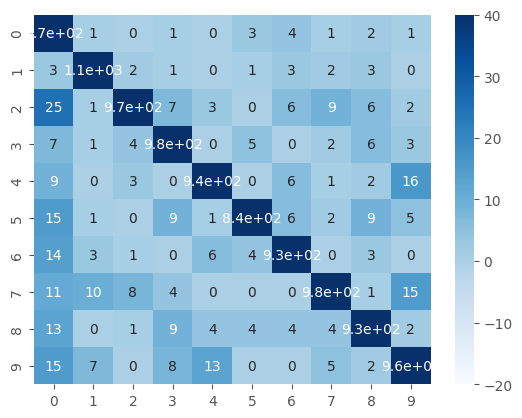

In [ ]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Ytrue, Ypredicted)
print(cm)
df_cm = pd.DataFrame(cm)

#plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, vmin=-20, vmax=40, cmap="Blues")


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(Ytrue, Ypredicted))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       980
           1       0.98      0.99      0.98      1135
           2       0.98      0.94      0.96      1032
           3       0.96      0.97      0.97      1010
           4       0.97      0.96      0.97       982
           5       0.98      0.95      0.96       892
           6       0.97      0.97      0.97       958
           7       0.97      0.95      0.96      1028
           8       0.96      0.96      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000

